In [1]:
from model import SVMHardMargin, SVMSoftMargin
import matplotlib.pyplot as plt

# Hard margin

In [2]:
import numpy as np

def make_separable(n=100, dim=2, gap=4.0, seed=0):
    rng = np.random.default_rng(seed)
    half = n // 2
    # two clusters offset along a random direction by `gap`
    direction = rng.standard_normal(dim)
    direction /= np.linalg.norm(direction)
    offset = gap * direction

    X_pos = rng.standard_normal((half, dim)) + offset
    X_neg = rng.standard_normal((half, dim)) - offset

    X = np.vstack([X_pos, X_neg]).astype(np.float64)
    y = np.concatenate([np.ones(half), -np.ones(half)]).astype(np.float64)

    # shuffle so the classes aren't blocked
    perm = rng.permutation(n)
    return X[perm], y[perm]

In [3]:
X, y= make_separable()

clf = SVMHardMargin()
clf.fit(X, y)

pred = clf.predict(X)
acc = (pred == y).mean()
acc

np.float64(1.0)

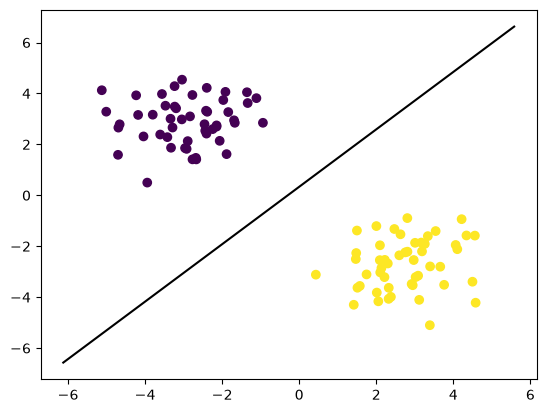

In [4]:
plt.scatter(X[:,0], X[:,1], label="", marker="o", c =y)
x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
plt.plot(x1, (-clf.b -clf.w[0] * x1)/clf.w[1], "k-")



# Soft Margin

In [5]:
def make_overlapping(n=200, dim=2, gap=1.0, spread=1.0, seed=0):
    rng = np.random.default_rng(seed)
    half = n // 2
    direction = rng.standard_normal(dim)
    direction /= np.linalg.norm(direction)
    offset = gap * direction

    X_pos = spread * rng.standard_normal((half, dim)) + offset
    X_neg = spread * rng.standard_normal((half, dim)) - offset

    X = np.vstack([X_pos, X_neg]).astype(np.float64)
    y = np.concatenate([np.ones(half), -np.ones(half)]).astype(np.float64)

    perm = rng.permutation(n)
    return X[perm], y[perm]

In [6]:
X, y = make_overlapping()

clf = SVMSoftMargin()
clf.fit(X, y)


In [7]:
pred = clf.predict(X)

acc = (pred ==y).mean()
acc

np.float64(0.845)

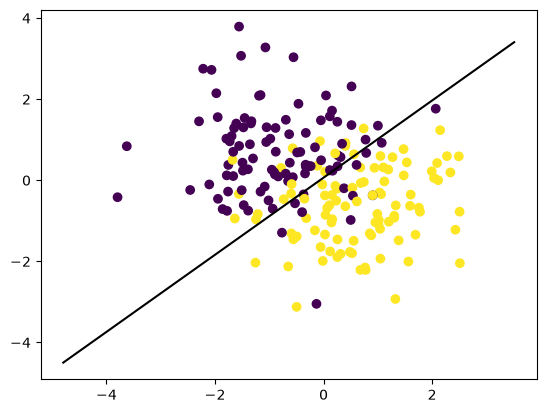

In [8]:
plt.scatter(X[:,0], X[:,1], label="", marker="o", c =y)
x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
plt.plot(x1, (-clf.b -clf.w[0] * x1)/clf.w[1], "k-")